# Project 2: Multi-Layer Perceptrons (MLPs) in PyTorch

In this project, you will implement and analyze a multilayer perceptron (MLP) for digit classification on MNIST, and evaluate cross-dataset generalization on USPS. You’ll compare different activation functions (None, ReLU, Sigmoid, Tanh), visualize learning dynamics, and report the best USPS test accuracy from training history. 

By the end, you should be able to:
- Build an MLP with configurable **hidden sizes** and **activation**.
- Train and evaluate models on **MNIST**, and test on **USPS** via `extra_test_loaders`.
- Compare activations (**None, ReLU, Sigmoid, Tanh**) using accuracy/loss curves.
- Extract and report the **best USPS test accuracy** from `history['usps_acc']`.

***NOTE:***
When filling in the code, please REMOVE the `pass` and `None` statement.
DO NOT remove the TODO coding highlight in your submission.


### <span style="color: red;"> Grading Criteria:</span>
- Code quality and implementation (3 pts)
- ***Final USPS Test Accuracy in Part 7 II*** must achieve > **58% accuracy on the USPS test set** to meet the deliverable and obtain full credit for testing/generalization. (5 points)
- Analysis and answers to questions (4 pts)
- **Total: 12 points**

In [1]:
# # Google Colab Setup (Comment out for local computer running)
################################################################################
# Uncomment and set the path to your project folder in Google Drive
################################################################################
# from google.colab import drive
# drive.mount('/content/drive')

# FOLDERNAME = 'cpsc8430/assignments/project2/'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# # Now that we've mounted your Drive, this ensures that
# # the Python interpreter of the Colab VM can load
# # python files from within it.

# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))
# %cd /content/drive/My\ Drive/$FOLDERNAME

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

import os
import bz2
import subprocess
from urllib.request import urlretrieve

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set style for better plots
plt.rcParams['figure.figsize'] = (12, 8)

Using device: cpu


## Part 1: Load and Preprocess MNIST Dataset

First, let's load the MNIST dataset and prepare it for training and validation. Then load USPS dataset for testing.

Training samples: 60000
Test samples: 10000
Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


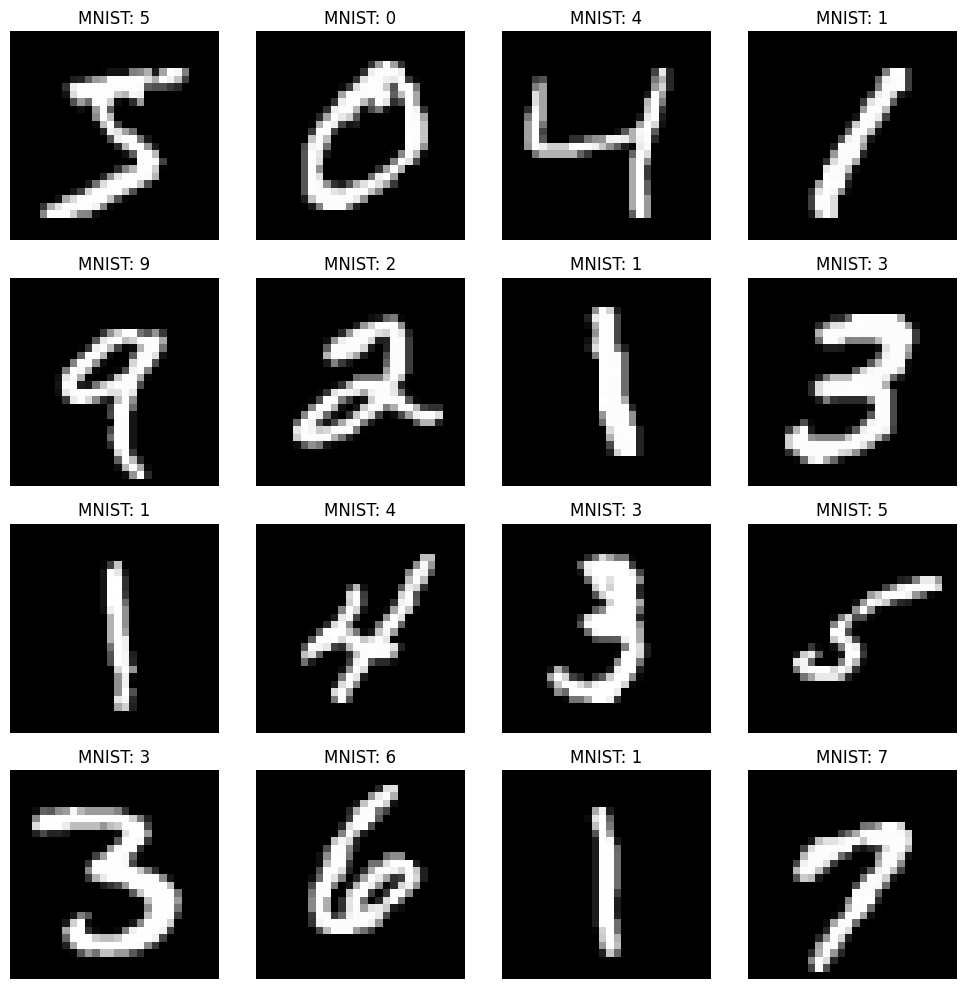

USPS test samples: 2007
USPS label set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


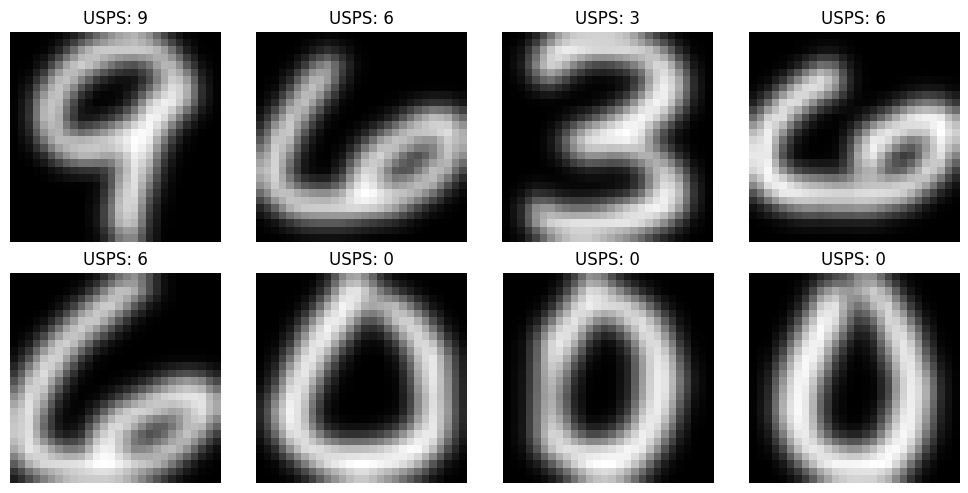

In [3]:
# Data root for caching datasets
data_root = 'cpsc8430/datasets'
os.makedirs(data_root, exist_ok=True)

# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Load MNIST dataset
mnist_root = os.path.join(data_root, 'MNIST')
train_dataset = datasets.MNIST(mnist_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(mnist_root, train=False, transform=transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Classes: {train_dataset.classes}')

# Visualize some sample MNIST images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i in range(16):
    img, label = train_dataset[i]
    ax = axes[i // 4, i % 4]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'MNIST: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# USPS dataset for cross-domain testing
usps_url = 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/multiclass/usps.t.bz2'
usps_root = os.path.join(data_root, 'USPS')
usps_bz2_path = os.path.join(usps_root, 'usps.t.bz2')
usps_libsvm_path = os.path.join(usps_root, 'usps.t')
os.makedirs(usps_root, exist_ok=True)

if not os.path.exists(usps_libsvm_path):
    if not os.path.exists(usps_bz2_path):
        print('Downloading USPS test dataset...')
        subprocess.run(['curl', '-k', '-L', usps_url, '-o', usps_bz2_path])
        # ssl._create_default_https_context = ssl._create_unverified_context
        # urlretrieve(usps_url, usps_bz2_path)
    print('Decompressing USPS dataset...')
    with bz2.open(usps_bz2_path, 'rb') as bz2_file, open(usps_libsvm_path, 'wb') as out_file:
        out_file.write(bz2_file.read())

def load_usps_dataset(libsvm_path):
    images, labels = [], []
    with open(libsvm_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            # The labels in the USPS dataset are 1-indexed, except for 0 which is 10.
            # We need to map them to 0-9.
            label = int(float(parts[0]))
            label = label - 1

            labels.append(label)

            pixels = torch.zeros(16 * 16, dtype=torch.float32)
            for kv in parts[1:]:
                idx, value = kv.split(':')
                pixels[int(idx) - 1] = float(value)
            images.append(pixels)

    images = torch.stack(images).view(-1, 1, 16, 16)
    images = (images + 1.0) / 2.0  # Scale from [-1, 1] to [0, 1]
    resized = F.interpolate(images, size=(28, 28), mode='bilinear', align_corners=False)
    normalized = (resized - 0.1307) / 0.3081
    labels = torch.tensor(labels, dtype=torch.long)
    return normalized, labels, resized

usps_images, usps_labels, usps_resized = load_usps_dataset(usps_libsvm_path)
usps_dataset = torch.utils.data.TensorDataset(usps_images, usps_labels)
usps_test_loader = DataLoader(usps_dataset, batch_size=batch_size, shuffle=False)

print(f'USPS test samples: {len(usps_dataset)}')
print(f'USPS label set: {sorted(usps_labels.unique().tolist())}')

# Visualize USPS samples after resizing to 28x28
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(8):
    ax = axes[i // 4, i % 4]
    img = usps_resized[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'USPS: {int(usps_labels[i].item())}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Part 2: Implement MLP Class

**TODO: Implement a flexible MLP class that can handle different architectures**

The MLP should:
- Support variable number of hidden layers
- Allow different activation functions (ReLU, Tanh, Sigmoid, etc.)
- Option to disable activation functions (for comparison with linear models)
- Proper initialization of weights and biases

In [4]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[128, 64], num_classes=10, activation='relu', use_activation=True):
        """
        Multi-Layer Perceptron implementation
        
        Args:
            input_size (int): Size of input features (784 for MNIST)
            hidden_sizes (list): List of hidden layer sizes
            num_classes (int): Number of output classes (10 for MNIST)
            activation (str): Activation function type ('relu', 'tanh', 'sigmoid', 'leaky_relu')
            use_activation (bool): Whether to use activation functions
        """
        super(MLP, self).__init__()
        self.input_size = input_size
        self.use_activation = use_activation
        
        # Define activation function based on the 'activation' parameter
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.1)
        else:
            self.activation = nn.ReLU()  # default
        
        # Build layers dynamically
        layers = []
        prev_size = input_size

        ################################################################################
        # TODO: Implement MLP architecture
        # HINT: Use a loop to add nn.Linear layers for each hidden size in hidden_sizes.
        #       After each hidden layer, add the activation function if use_activation is True.
        #       Finally, add the output layer (nn.Linear) with num_classes outputs.
        ################################################################################
        # *****START OF SOLUTION*****
        for layer in range(0, len(hidden_sizes)):
            layers.append(nn.Linear(prev_size, hidden_sizes[layer]))
            if use_activation == True:
                layers.append(self.activation)

            prev_size = hidden_sizes[layer]
        
        layers.append(nn.Linear(prev_size, num_classes))
                
        # *****END OF SOLUTION*****
        ################################################################################
        
        # Create sequential model
        self.layers = nn.Sequential(*layers)        
    
    def forward(self, x):
        """
        Forward pass of the MLP
        
        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28) for MNIST
        
        Returns:
            Output tensor of shape (batch_size, num_classes)
        """
        ################################################################################
        # TODO: Implement forward pass
        # HINT: Use the .view() function to flatten the input tensor from (batch_size, 1, 28, 28) to (batch_size, 784)
        ################################################################################
        # *****START OF SOLUTION*****

        x = x.view(-1, 784) # Define the flattening operation here
        
        # *****END OF SOLUTION*****
        ################################################################################

        # Pass through all layers
        return self.layers(x)        
    
    def get_num_parameters(self):
        """Return the total number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test the model
model = MLP()
print(f'Model architecture:\n{model}')
print(f'Number of parameters: {model.get_num_parameters():,}')

# Test forward pass
sample_batch = torch.randn(32, 1, 28, 28)
output = model(sample_batch)
print(f'Input shape: {sample_batch.shape}')
print(f'Output shape: {output.shape}')

Model architecture:
MLP(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Number of parameters: 109,386
Input shape: torch.Size([32, 1, 28, 28])
Output shape: torch.Size([32, 10])


Now test the untrained MLP's performance, which initialize its weights randomly, on both 
- MNIST test set
- USPS test set. 

This shows the behavior of a randomly initialized network (i.e., a "chance" baseline) and helps compare against trained models.

In [5]:
# Instantiate untrained model (named MLP_untrained as requested)
MLP_untrained = MLP()

# Explicit random initialization for all linear layers so the model is not using
# the default initialization (this makes the baseline reproducible if seeds are set).
def random_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.05)  # small Gaussian weights
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)             # zero biases

MLP_untrained.apply(random_init)

# Move to device and switch to evaluation mode (disables dropout, batchnorm updates, etc.)
MLP_untrained = MLP_untrained.to(device)
MLP_untrained.eval()

criterion_untrained = nn.CrossEntropyLoss()

# Evaluate on MNIST test set (real data, not random inputs) to get the untrained baseline.
mnist_test_loss = 0.0
mnist_correct = 0
mnist_total = 0

with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = MLP_untrained(data)
        loss = criterion_untrained(outputs, targets)
        mnist_test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        mnist_total += targets.size(0)
        mnist_correct += (predicted == targets).sum().item()

avg_mnist_loss = mnist_test_loss / len(test_loader)
mnist_accuracy = 100.0 * mnist_correct / mnist_total

print(f"MLP_untrained - MNIST Test Loss: {avg_mnist_loss:.4f}, Accuracy: {mnist_accuracy:.2f}%")

# Evaluate on USPS test set (cross-domain baseline) to see how an untrained model
# performs on a different but related dataset (resized/normalized USPS).
usps_test_loss = 0.0
usps_correct = 0
usps_total = 0

with torch.no_grad():
    for data, targets in usps_test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = MLP_untrained(data)
        loss = criterion_untrained(outputs, targets)
        usps_test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        usps_total += targets.size(0)
        usps_correct += (predicted == targets).sum().item()

avg_usps_loss = usps_test_loss / len(usps_test_loader)
usps_accuracy = 100.0 * usps_correct / usps_total

print(f"MLP_untrained - USPS Test Loss: {avg_usps_loss:.4f}, Accuracy: {usps_accuracy:.2f}%")


MLP_untrained - MNIST Test Loss: 2.3248, Accuracy: 9.12%
MLP_untrained - USPS Test Loss: 2.2505, Accuracy: 20.18%


## Part 3: Training and Evaluation Functions

These functions will be used throughout the experiments to train and evaluate different model configurations.

In [6]:
def train_model(model, train_loader, test_loader, optimizer, criterion, num_epochs=10, device='cpu', extra_test_loaders=None):
    """
    Train a model and return training history
    
    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        optimizer: PyTorch optimizer
        criterion: Loss function
        num_epochs: Number of training epochs
        device: Device to train on ('cpu' or 'cuda')
        extra_test_loaders (dict): Optional mapping of name -> DataLoader for additional evaluation sets
    
    Returns:
        Dictionary containing training history
    """
    model = model.to(device)
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    extra_test_loaders = extra_test_loaders or {}
    for name in extra_test_loaders.keys():
        history[f'{name}_loss'] = []
        history[f'{name}_acc'] = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (data, targets) in enumerate(train_loader):
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()

        # Evaluation phase on MNIST test set
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += targets.size(0)
                test_correct += (predicted == targets).sum().item()

        extra_metrics = {}
        with torch.no_grad():
            for name, extra_loader in extra_test_loaders.items():
                extra_loss = 0.0
                extra_correct = 0
                extra_total = 0

                for data, targets in extra_loader:
                    data, targets = data.to(device), targets.to(device)
                    outputs = model(data)
                    loss = criterion(outputs, targets)

                    extra_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    extra_total += targets.size(0)
                    extra_correct += (predicted == targets).sum().item()

                avg_extra_loss = extra_loss / len(extra_loader)
                extra_accuracy = 100.0 * extra_correct / extra_total
                history[f'{name}_loss'].append(avg_extra_loss)
                history[f'{name}_acc'].append(extra_accuracy)
                extra_metrics[name] = (avg_extra_loss, extra_accuracy)

        # Calculate averages
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        train_accuracy = 100.0 * train_correct / train_total
        test_accuracy = 100.0 * test_correct / test_total

        # Store history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_accuracy)

        extra_msg = ''
        if extra_metrics:
            pretty_metrics = []
            for name, (loss_value, acc_value) in extra_metrics.items():
                title = name.replace('_', ' ').title()
                pretty_metrics.append(f"{title} Loss: {loss_value:.4f}, {title} Acc: {acc_value:.2f}%")
            extra_msg = ' - ' + ' - '.join(pretty_metrics)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% - "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.2f}%"
              f"{extra_msg}")

    return history

def plot_training_history(history, title="Training History"):
    """
    Plot training and validation curves
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['test_loss'], label='Test Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
    ax2.plot(history['test_acc'], label='Test Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


## Part 4: Experiment 1 - Importance of Activation Functions

**TODO: Compare MLPs with and without activation functions**

This experiment demonstrates why activation functions are crucial for neural networks.

In [7]:
# Compare MLP with and without activation functions
print("="*60)
print("EXPERIMENT 1: MLP WITHOUT ACTIVATION FUNCTIONS")
print("="*60)

################################################################################
# TODO: Create an MLP, named '''model_no_activation''', with two hidden layers
# and set '''use_activation=False''' to DISABLE activations
################################################################################
# *****START OF SOLUTION*****

model_no_activation = MLP(use_activation=False) # Define the MLP model without activation functions here

# *****END OF SOLUTION*****
################################################################################

model_no_activation.apply(random_init)  # Re-initialize weights for fair comparison
model_no_activation = model_no_activation.to(device)  
optimizer_no_activation = optim.Adam(model_no_activation.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

history_no_activation = train_model(
    model_no_activation, train_loader, test_loader, 
    optimizer_no_activation, criterion, num_epochs=10, device=device
)

print("\n" + "="*60)
print("EXPERIMENT 2: MLP WITH ReLU ACTIVATION FUNCTIONS")
print("="*60)

################################################################################
# TODO: Create and train a new MLP model, named ```model_with_relu```
# with SAME shape as ```model_no_activation``, but using ReLU activation functions
################################################################################
# *****START OF SOLUTION*****

model_with_relu = MLP(activation="relu") # Define the MLP model with ReLU activation functions here

# *****END OF SOLUTION*****
################################################################################

model_with_relu.apply(random_init)  # Re-initialize weights for fair comparison
model_with_relu = model_with_relu.to(device)  
optimizer_with_relu = optim.Adam(model_with_relu.parameters(), lr=0.001)

history_with_relu = train_model(
    model_with_relu, train_loader, test_loader, 
    optimizer_with_relu, criterion, num_epochs=10, device=device
)

print("\n" + "="*60)
print("EXPERIMENT 3: MLP WITH SIGMOID ACTIVATION FUNCTIONS")
print("="*60)

################################################################################
# TODO: Create and train a new MLP model, named ```model_with_sigmoid```
# with SAME shape as before, but using Sigmoid activation functions
################################################################################
# *****START OF SOLUTION*****

model_with_sigmoid = MLP(activation="sigmoid") # Define the MLP model with Sigmoid activation functions here

# *****END OF SOLUTION*****
################################################################################

model_with_sigmoid.apply(random_init)  # Re-initialize weights for fair comparison
model_with_sigmoid = model_with_sigmoid.to(device)   
optimizer_with_sigmoid = optim.Adam(model_with_sigmoid.parameters(), lr=0.001)

history_with_sigmoid = train_model(
    model_with_sigmoid, train_loader, test_loader, 
    optimizer_with_sigmoid, criterion, num_epochs=10, device=device
)

print("\n" + "="*60)
print("EXPERIMENT 4: MLP WITH TANH ACTIVATION FUNCTIONS")
print("="*60)

################################################################################
# TODO: Create and train a new MLP model, named ```model_with_tanh```
# with SAME shape as before, but using Tanh activation functions
################################################################################
# *****START OF SOLUTION*****

model_with_tanh = MLP(activation="tanh") # Define the MLP model with Tanh activation functions here

# *****END OF SOLUTION*****
################################################################################

model_with_tanh.apply(random_init)  # Re-initialize weights for fair comparison
model_with_tanh = model_with_tanh.to(device)   
optimizer_with_tanh = optim.Adam(model_with_tanh.parameters(), lr=0.001)

history_with_tanh = train_model(
    model_with_tanh, train_loader, test_loader, 
    optimizer_with_tanh, criterion, num_epochs=10, device=device
)


EXPERIMENT 1: MLP WITHOUT ACTIVATION FUNCTIONS
Epoch [1/10] - Train Loss: 0.3883, Train Acc: 88.74% - Test Loss: 0.2930, Test Acc: 91.74%
Epoch [2/10] - Train Loss: 0.3055, Train Acc: 91.44% - Test Loss: 0.2879, Test Acc: 91.59%
Epoch [3/10] - Train Loss: 0.2958, Train Acc: 91.63% - Test Loss: 0.2939, Test Acc: 91.35%
Epoch [4/10] - Train Loss: 0.2873, Train Acc: 91.90% - Test Loss: 0.3038, Test Acc: 91.30%
Epoch [5/10] - Train Loss: 0.2844, Train Acc: 92.03% - Test Loss: 0.2788, Test Acc: 92.12%
Epoch [6/10] - Train Loss: 0.2810, Train Acc: 92.07% - Test Loss: 0.2798, Test Acc: 91.98%
Epoch [7/10] - Train Loss: 0.2788, Train Acc: 92.22% - Test Loss: 0.2976, Test Acc: 91.70%
Epoch [8/10] - Train Loss: 0.2774, Train Acc: 92.16% - Test Loss: 0.2845, Test Acc: 91.95%
Epoch [9/10] - Train Loss: 0.2754, Train Acc: 92.33% - Test Loss: 0.2799, Test Acc: 91.97%
Epoch [10/10] - Train Loss: 0.2712, Train Acc: 92.28% - Test Loss: 0.2845, Test Acc: 92.07%

EXPERIMENT 2: MLP WITH ReLU ACTIVATION FU

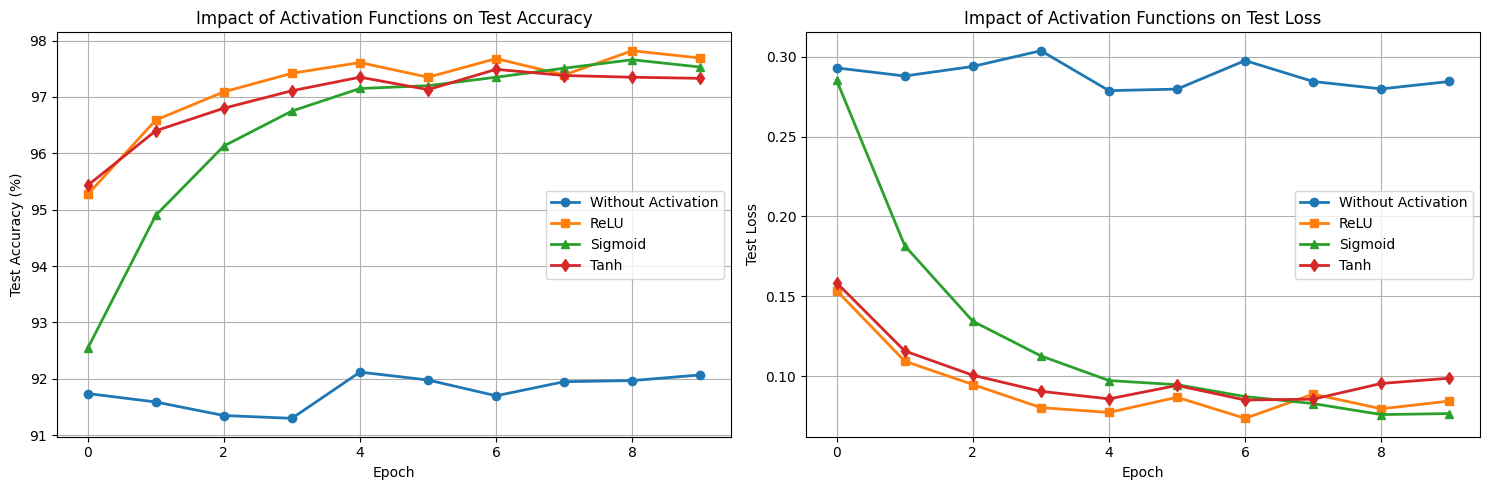

Final Test Accuracy - Without Activation: 92.07%
Final Test Accuracy - ReLU: 97.69%
Final Test Accuracy - Sigmoid: 97.53%
Final Test Accuracy - Tanh: 97.33%

Improvements over No Activation:
ReLU: 5.62%
Sigmoid: 5.46%
Tanh: 5.26%


In [8]:
# Compare the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot test accuracy comparison ---
ax1.plot(history_no_activation['test_acc'], label='Without Activation', marker='o', linewidth=2)
ax1.plot(history_with_relu['test_acc'], label='ReLU', marker='s', linewidth=2)
ax1.plot(history_with_sigmoid['test_acc'], label='Sigmoid', marker='^', linewidth=2)
ax1.plot(history_with_tanh['test_acc'], label='Tanh', marker='d', linewidth=2)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Impact of Activation Functions on Test Accuracy')
ax1.legend()
ax1.grid(True)

# --- Plot test loss comparison ---
ax2.plot(history_no_activation['test_loss'], label='Without Activation', marker='o', linewidth=2)
ax2.plot(history_with_relu['test_loss'], label='ReLU', marker='s', linewidth=2)
ax2.plot(history_with_sigmoid['test_loss'], label='Sigmoid', marker='^', linewidth=2)
ax2.plot(history_with_tanh['test_loss'], label='Tanh', marker='d', linewidth=2)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Loss')
ax2.set_title('Impact of Activation Functions on Test Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print final test accuracy of each model
print(f"Final Test Accuracy - Without Activation: {history_no_activation['test_acc'][-1]:.2f}%")
print(f"Final Test Accuracy - ReLU: {history_with_relu['test_acc'][-1]:.2f}%")
print(f"Final Test Accuracy - Sigmoid: {history_with_sigmoid['test_acc'][-1]:.2f}%")
print(f"Final Test Accuracy - Tanh: {history_with_tanh['test_acc'][-1]:.2f}%")

print("\nImprovements over No Activation:")
print(f"ReLU: {history_with_relu['test_acc'][-1] - history_no_activation['test_acc'][-1]:.2f}%")
print(f"Sigmoid: {history_with_sigmoid['test_acc'][-1] - history_no_activation['test_acc'][-1]:.2f}%")
print(f"Tanh: {history_with_tanh['test_acc'][-1] - history_no_activation['test_acc'][-1]:.2f}%")


## Part 5: Experiment 2 - Learning Rate Impact

**TODO: Experiment with different learning rates**

This experiment shows how learning rate affects training stability and convergence speed.

In [10]:
# Test different learning rates
learning_rates = [0.5, 0.1, 0.01, 0.001, 0.0001]
lr_histories = {}

################################################################################
# TODO Set `num_epochs` appropriately for training with different learning rates.:
# 1) Set `num_epochs` to a value large enough so training converges for all LRs.
#    Start with 15 and increase (e.g., 30-50) if validation/test accuracy is still improving.
# 2) After training, inspect the train/test loss & accuracy curves (plotting cells)
#    to verify convergence. If curves are still improving at the final epoch, raise
#    `num_epochs`.
# 3) Note LR-specific guidance:
#    - Small LR (e.g., 1e-4): may require many more epochs to converge.
#    - Large LR (e.g., 1e-1): may be unstable; if so, reduce LR instead of only
#      increasing epochs.
# Hint: Choose `num_epochs` so that test accuracy/loss plateaus for ~5 consecutive
#       epochs (no meaningful improvement).
################################################################################
 # *****START OF SOLUTION*****

num_epochs = 15 # Set an appropriate number of epochs here

 # *****END OF SOLUTION*****
################################################################################

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Testing learning rate: {lr}")
    print(f"{'='*50}")
    
    ################################################################################
    # TODO: create a new MLP with the same architecture as `model_no_activation`
    # using ReLU activations.
    ################################################################################
    # *****START OF SOLUTION*****

    model = MLP(activation="relu") # Define the MLP model with ReLU activation functions here

    # *****END OF SOLUTION*****
    ################################################################################

    model.apply(random_init)  # Re-initialize weights for fair comparison
    model = model.to(device)     
    # Use SGD optimizer to see LR effects more clearly
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # Train for 15 epochs
    history = train_model(model, train_loader, test_loader, optimizer, criterion, 
                         num_epochs=num_epochs, device=device)
    # Store results in lr_histories dictionary
    lr_histories[lr] = history


Testing learning rate: 0.5
Epoch [1/15] - Train Loss: nan, Train Acc: 10.93% - Test Loss: nan, Test Acc: 9.80%
Epoch [2/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [3/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [4/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [5/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [6/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [7/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [8/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [9/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [10/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [11/15] - Train Loss: nan, Train Acc: 9.87% - Test Loss: nan, Test Acc: 9.80%
Epoch [12/15] - Train Loss: nan, Train Acc: 9.87% - Test


This cell visualizes and summarizes the effect of different learning rates on training dynamics. Specifically it:

- Plots four subplots comparing each learning rate's:
    - MNIST test accuracy per epoch
    - MNIST test loss per epoch
    - Training accuracy per epoch
    - Training loss per epoch
- Uses the `lr_histories` produced by training runs for each learning rate in `learning_rates`.
- Prints a compact summary table showing each LR's final test/train accuracy and a simple stability metric (std of the last 5 test-loss values).

**NOTE:Use these plots and the stability values to identify:**
- **Too-large LR (unstable/oscillating curves)**
- **Too-small LR (very slow improvement)**
- **Reasonable numbers of epochs (ensure training convergence)**

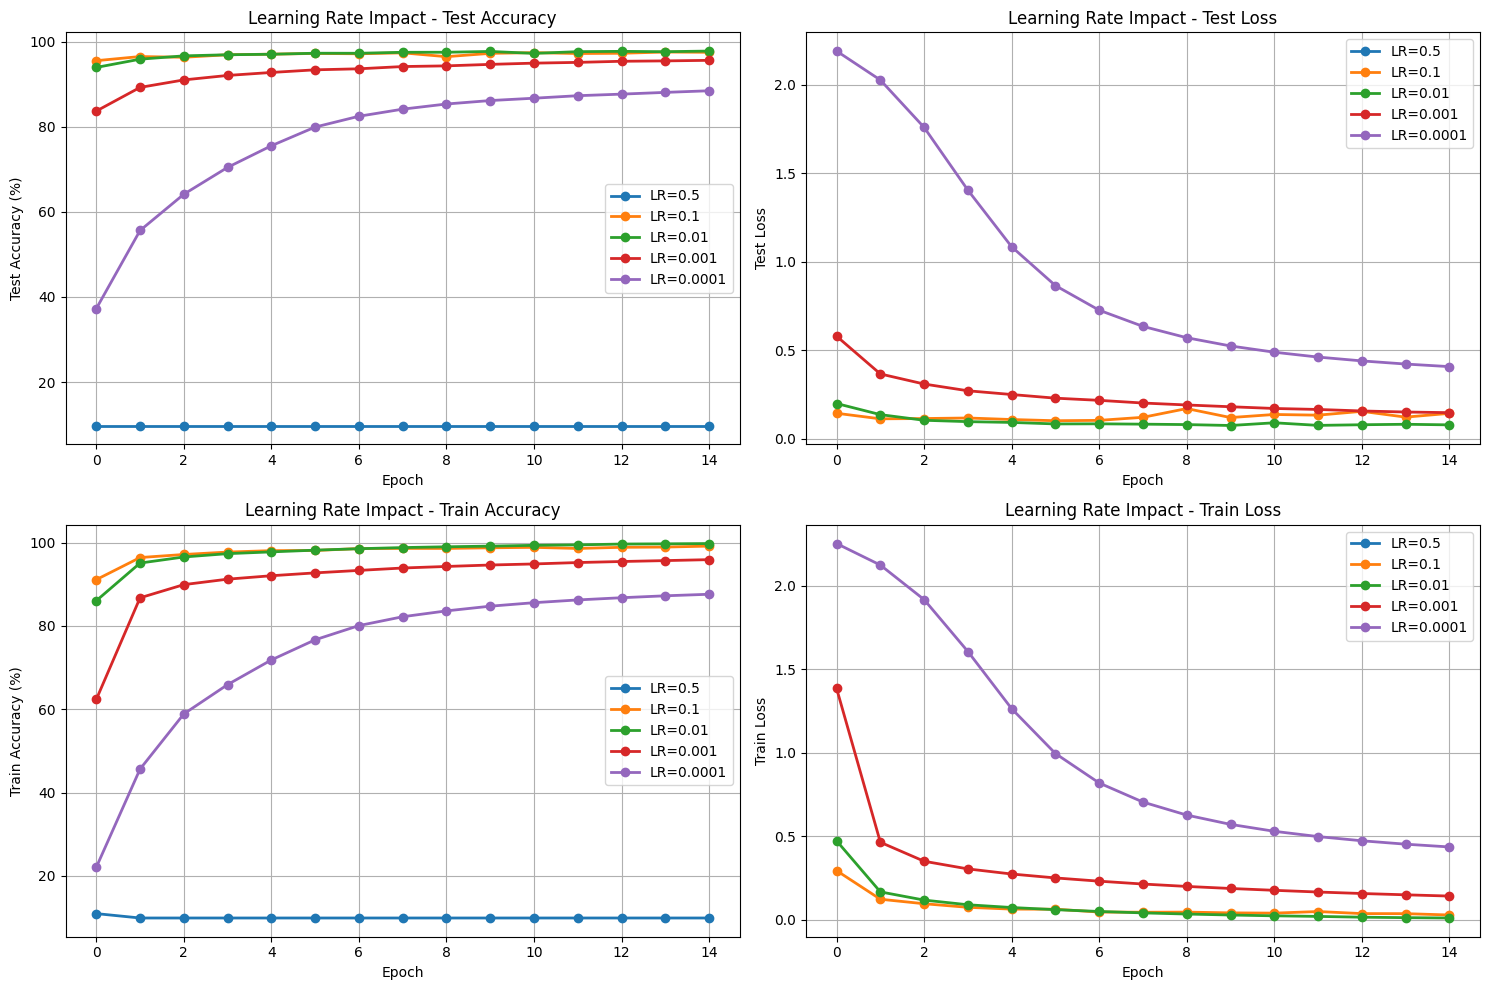


Learning Rate Summary:
LR		Final Test Acc	Final Train Acc	Stability
------------------------------------------------------------
0.5		9.80%		9.87%		nan
0.1		97.49%		99.15%		0.0108
0.01		97.78%		99.76%		0.0050
0.001		95.60%		95.90%		0.0088
0.0001		88.45%		87.59%		0.0288


In [11]:
# Plot learning rate comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Test accuracy
for lr in learning_rates:
    ax1.plot(lr_histories[lr]['test_acc'], label=f'LR={lr}', marker='o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Learning Rate Impact - Test Accuracy')
ax1.legend()
ax1.grid(True)

# Test loss
for lr in learning_rates:
    ax2.plot(lr_histories[lr]['test_loss'], label=f'LR={lr}', marker='o', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Loss')
ax2.set_title('Learning Rate Impact - Test Loss')
ax2.legend()
ax2.grid(True)

# Train accuracy
for lr in learning_rates:
    ax3.plot(lr_histories[lr]['train_acc'], label=f'LR={lr}', marker='o', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Train Accuracy (%)')
ax3.set_title('Learning Rate Impact - Train Accuracy')
ax3.legend()
ax3.grid(True)

# Train loss
for lr in learning_rates:
    ax4.plot(lr_histories[lr]['train_loss'], label=f'LR={lr}', marker='o', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Train Loss')
ax4.set_title('Learning Rate Impact - Train Loss')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

# Print summary
print("\nLearning Rate Summary:")
print("LR\t\tFinal Test Acc\tFinal Train Acc\tStability")
print("-" * 60)
for lr in learning_rates:
    test_acc = lr_histories[lr]['test_acc'][-1]
    train_acc = lr_histories[lr]['train_acc'][-1]
    # Simple stability measure - variance in last 5 epochs
    stability = np.std(lr_histories[lr]['test_loss'][-5:])
    print(f"{lr}\t\t{test_acc:.2f}%\t\t{train_acc:.2f}%\t\t{stability:.4f}")

## Part 6: Experiment 3 - Optimizer Comparison

**TODO: Compare different optimizers (SGD, Adam, AdamW)**

This experiment shows the robustness and performance characteristics of different optimizers.

In [12]:
# Compare different optimizers with the same learning rate
optimizer_configs = [
    ('SGD', lambda params: optim.SGD(params, lr=0.01, momentum=0.9)),
    ('Adam', lambda params: optim.Adam(params, lr=0.001)),
    ('AdamW', lambda params: optim.AdamW(params, lr=0.001, weight_decay=0.01))
]

optimizer_histories = {}

for name, optimizer_fn in optimizer_configs:
    print(f"\n{'='*50}")
    print(f"Testing {name} optimizer")
    print(f"{'='*50}")
    
    ################################################################################
    # TODO: Train models with the same architecture as `model_no_activation`
    # using ReLU activations.
    ################################################################################
    # *****START OF SOLUTION*****

    model = MLP(activation="relu") # Define the MLP model with ReLU activation functions here

    # *****END OF SOLUTION*****
    ################################################################################
    
    model.apply(random_init)  # Re-initialize weights for fair comparison
    model = model.to(device)
        
    # Use the optimizer_fn to create the optimizer
    optimizer = optimizer_fn(model.parameters())
    
    # Train for 15 epochs
    history = train_model(model, train_loader, test_loader, optimizer, criterion, 
                         num_epochs=15, device=device)
    # Store results in optimizer_histories dictionary
    optimizer_histories[name] = history


Testing SGD optimizer
Epoch [1/15] - Train Loss: 0.4571, Train Acc: 86.41% - Test Loss: 0.2042, Test Acc: 93.73%
Epoch [2/15] - Train Loss: 0.1667, Train Acc: 95.07% - Test Loss: 0.1333, Test Acc: 96.01%
Epoch [3/15] - Train Loss: 0.1181, Train Acc: 96.51% - Test Loss: 0.1165, Test Acc: 96.37%
Epoch [4/15] - Train Loss: 0.0899, Train Acc: 97.32% - Test Loss: 0.0932, Test Acc: 97.15%
Epoch [5/15] - Train Loss: 0.0715, Train Acc: 97.89% - Test Loss: 0.0867, Test Acc: 97.25%
Epoch [6/15] - Train Loss: 0.0577, Train Acc: 98.28% - Test Loss: 0.0808, Test Acc: 97.48%
Epoch [7/15] - Train Loss: 0.0488, Train Acc: 98.51% - Test Loss: 0.0872, Test Acc: 97.36%
Epoch [8/15] - Train Loss: 0.0414, Train Acc: 98.75% - Test Loss: 0.0777, Test Acc: 97.52%
Epoch [9/15] - Train Loss: 0.0331, Train Acc: 99.02% - Test Loss: 0.0749, Test Acc: 97.69%
Epoch [10/15] - Train Loss: 0.0285, Train Acc: 99.17% - Test Loss: 0.0785, Test Acc: 97.45%
Epoch [11/15] - Train Loss: 0.0234, Train Acc: 99.37% - Test Loss:

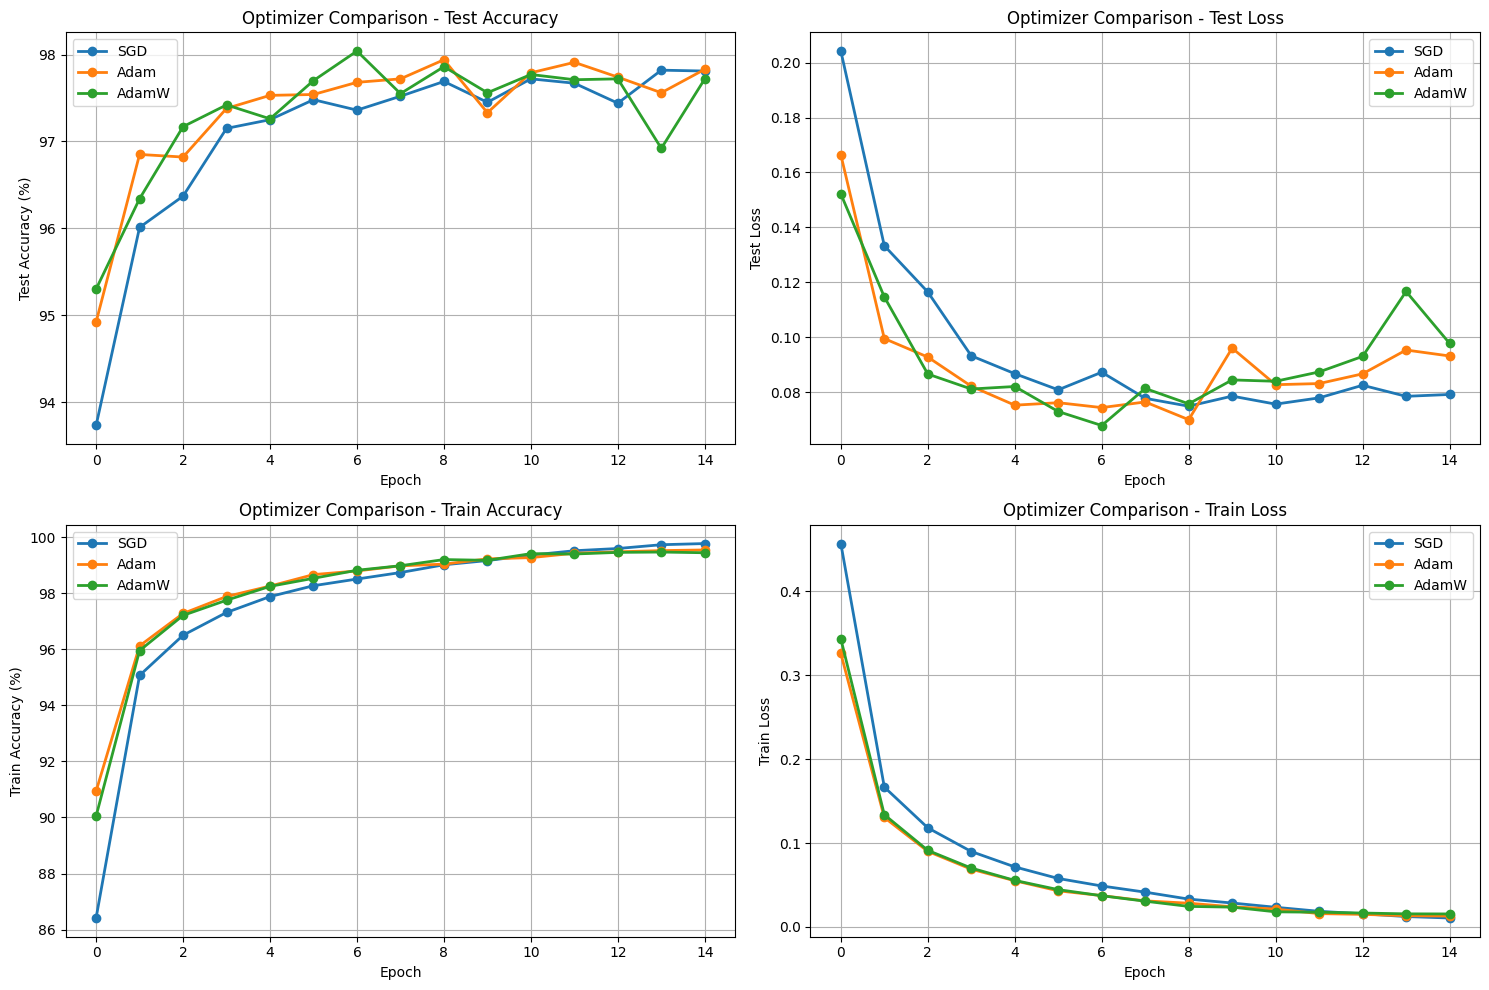


Optimizer Performance Summary:
Optimizer	Final Test Acc	Convergence Speed (Epochs to 95%)
-----------------------------------------------------------------
SGD		97.81%		1
Adam		97.83%		1
AdamW		97.72%		1


In [13]:
# Plot optimizer comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Test accuracy
for name in optimizer_histories.keys():
    ax1.plot(optimizer_histories[name]['test_acc'], label=f'{name}', marker='o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Optimizer Comparison - Test Accuracy')
ax1.legend()
ax1.grid(True)

# Test loss
for name in optimizer_histories.keys():
    ax2.plot(optimizer_histories[name]['test_loss'], label=f'{name}', marker='o', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Loss')
ax2.set_title('Optimizer Comparison - Test Loss')
ax2.legend()
ax2.grid(True)

# Train accuracy
for name in optimizer_histories.keys():
    ax3.plot(optimizer_histories[name]['train_acc'], label=f'{name}', marker='o', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Train Accuracy (%)')
ax3.set_title('Optimizer Comparison - Train Accuracy')
ax3.legend()
ax3.grid(True)

# Train loss
for name in optimizer_histories.keys():
    ax4.plot(optimizer_histories[name]['train_loss'], label=f'{name}', marker='o', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Train Loss')
ax4.set_title('Optimizer Comparison - Train Loss')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

print("\nOptimizer Performance Summary:")
print("Optimizer\tFinal Test Acc\tConvergence Speed (Epochs to 95%)")
print("-" * 65)
for name in optimizer_histories.keys():
    final_acc = optimizer_histories[name]['test_acc'][-1]
    # Find first epoch where accuracy reaches 95% of final accuracy
    target_acc = 0.95 * final_acc
    convergence_epoch = next((i for i, acc in enumerate(optimizer_histories[name]['test_acc']) 
                             if acc >= target_acc), len(optimizer_histories[name]['test_acc']))
    print(f"{name}\t\t{final_acc:.2f}%\t\t{convergence_epoch + 1}")

## Part 7: Experiment 4 - Overfitting and Underfitting

**TODO: Explore overfitting and underfitting by varying model capacity**

Goal
- Show how model capacity (number of layers / hidden units) affects training fit and generalization.
- Identify underfitting (low train & test accuracy) vs overfitting (high train acc, low test acc) and domain gap (MNIST vs USPS).

What to change (model_configs)
- Edit the list `model_configs` where each entry is a tuple: (name, hidden_sizes, num_epochs).
    - name: string label shown in plots/tables.
    - hidden_sizes: list of ints for hidden layer sizes (e.g., [128, 64]).
    - num_epochs: training epochs for that config.
- Provide at least 3–5 configs spanning very small → large capacity. Example suggestions:
    - ("Small", [16], 10)
    - ("Medium", [128, 64], 15)
    - ("Large", [256, 128, 32], 20)

What to inspect
- Train vs Test accuracy & loss curves per epoch.
- Train−Test gap (large gap → overfitting).
- MNIST − USPS gap (domain generalization).
- Parameter counts to relate capacity → overfitting.

Interpretation guidelines
- Underfitting: low train accuracy and low test accuracy → increase capacity, train longer, or reduce regularization.
- Overfitting: high train accuracy but significantly lower test accuracy (e.g., gap > 5%) → apply regularization or reduce capacity.
- Domain gap: if MNIST test acc ≫ USPS acc, model may be overfitting dataset-specific patterns;

In [14]:
################################################################################
# TODO: Train models with different capacities
# HINT: Define at least three MLPs named "Small", "Medium", "Large" with different hidden layer configs.
# Example configs you can use:
#   model_configs = [
#       ("Small", [16], 10), # single hidden layer with 16 units with 10 epochs
#       ("Medium", [128, 64], 15), # two hidden layers with 128 and 64 units with 15 epochs
#       ("Large", [256, 128, 32], 25) # three hidden layers with 256, 128, and 32 units with 25 epochs
################################################################################
# *****START OF SOLUTION*****

model_configs = [
    ("Small", [16], 10),
    ("Medium", [128, 64], 15),
    ("Large", [256, 128, 64], 20)
] # Define model configurations here

# *****END OF SOLUTION*****
################################################################################

capacity_histories = {}

for name, hidden_sizes, num_epochs in model_configs:
    print(f"\n{'='*50}")
    print(f"Testing model capacity: {name}")
    print(f"{'='*50}")
    
    # Create MLP with specified hidden_sizes
    model = MLP(hidden_sizes=hidden_sizes, activation='relu')
    # Print number of parameters for each model
    print(f"Number of parameters: {model.get_num_parameters():,}")

    model.apply(random_init)  # Re-initialize weights for fair comparison
    model = model.to(device)      
    
    # Use Adam optimizer with lr=0.001
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Train models for specified configurations
    history = train_model(model, train_loader, test_loader, optimizer, criterion, 
                         num_epochs=num_epochs, device=device, extra_test_loaders={'usps': usps_test_loader})
    # Store results in capacity_histories dictionary
    capacity_histories[name] = history
    



Testing model capacity: Small
Number of parameters: 12,730
Epoch [1/10] - Train Loss: 0.5514, Train Acc: 84.07% - Test Loss: 0.2961, Test Acc: 91.25% - Usps Loss: 2.3814, Usps Acc: 36.67%
Epoch [2/10] - Train Loss: 0.2873, Train Acc: 91.68% - Test Loss: 0.2643, Test Acc: 92.23% - Usps Loss: 2.4925, Usps Acc: 34.23%
Epoch [3/10] - Train Loss: 0.2527, Train Acc: 92.68% - Test Loss: 0.2374, Test Acc: 93.25% - Usps Loss: 2.7372, Usps Acc: 32.79%
Epoch [4/10] - Train Loss: 0.2262, Train Acc: 93.42% - Test Loss: 0.2229, Test Acc: 93.64% - Usps Loss: 2.9839, Usps Acc: 31.79%
Epoch [5/10] - Train Loss: 0.2072, Train Acc: 94.02% - Test Loss: 0.2047, Test Acc: 93.91% - Usps Loss: 3.1772, Usps Acc: 32.44%
Epoch [6/10] - Train Loss: 0.1931, Train Acc: 94.39% - Test Loss: 0.2074, Test Acc: 93.58% - Usps Loss: 3.5623, Usps Acc: 29.60%
Epoch [7/10] - Train Loss: 0.1813, Train Acc: 94.66% - Test Loss: 0.1882, Test Acc: 94.13% - Usps Loss: 3.7562, Usps Acc: 30.99%
Epoch [8/10] - Train Loss: 0.1711, Tr

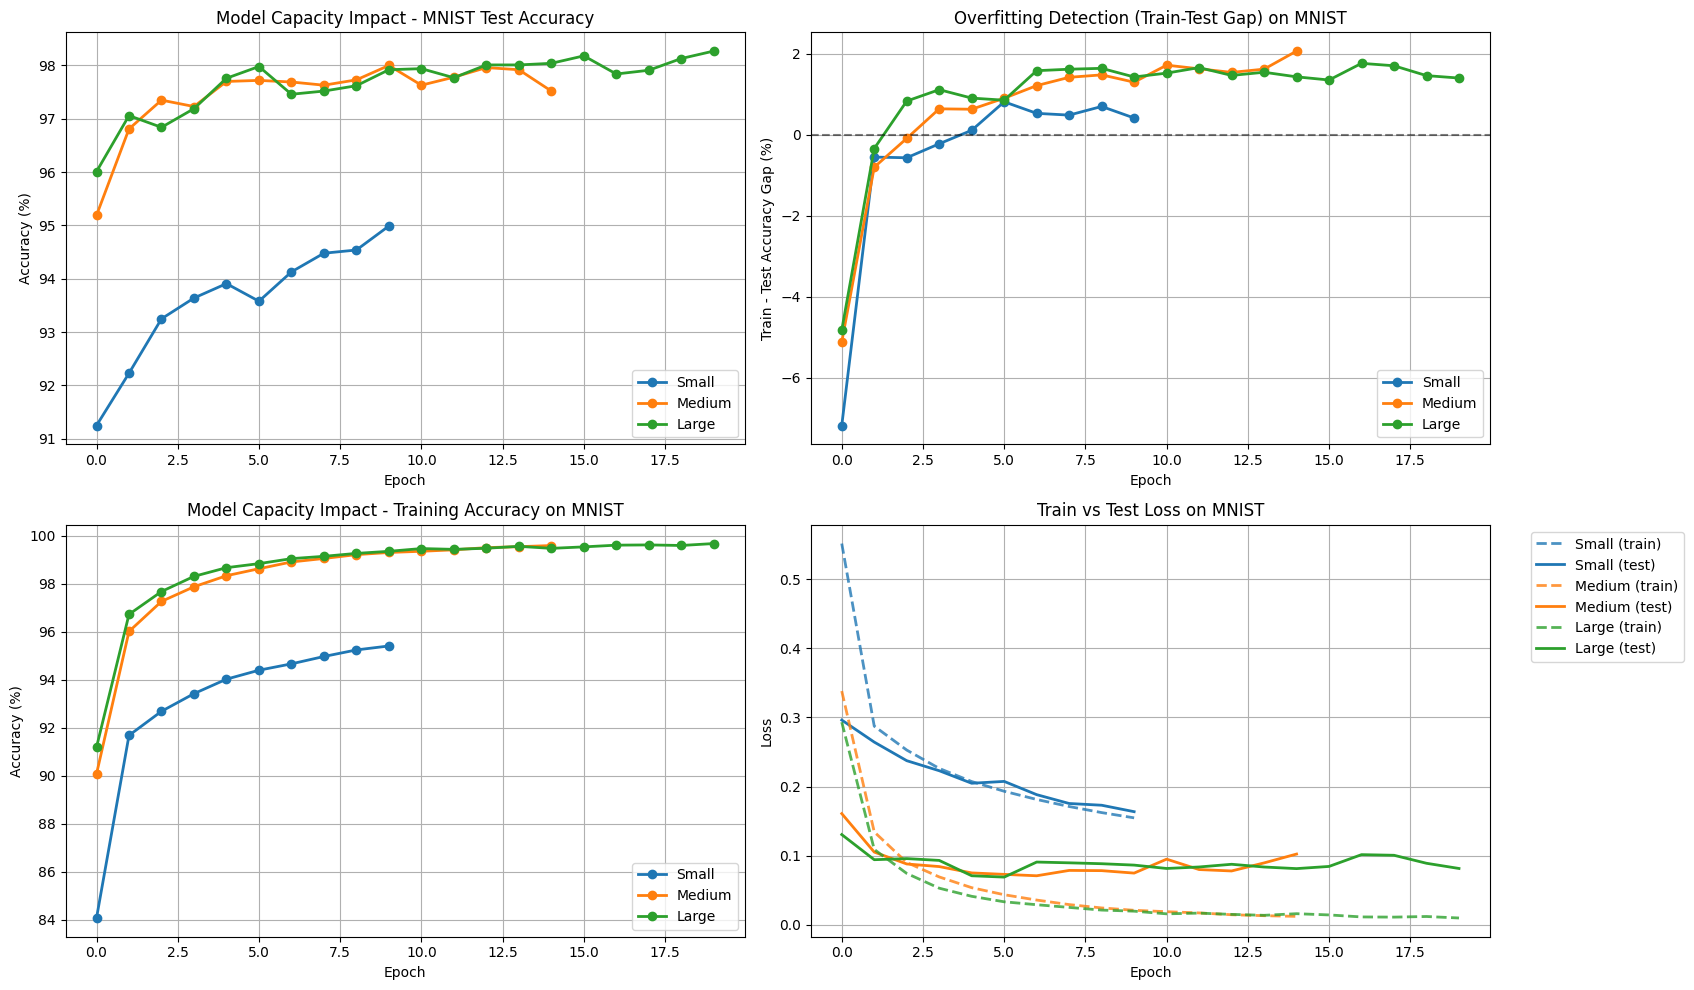

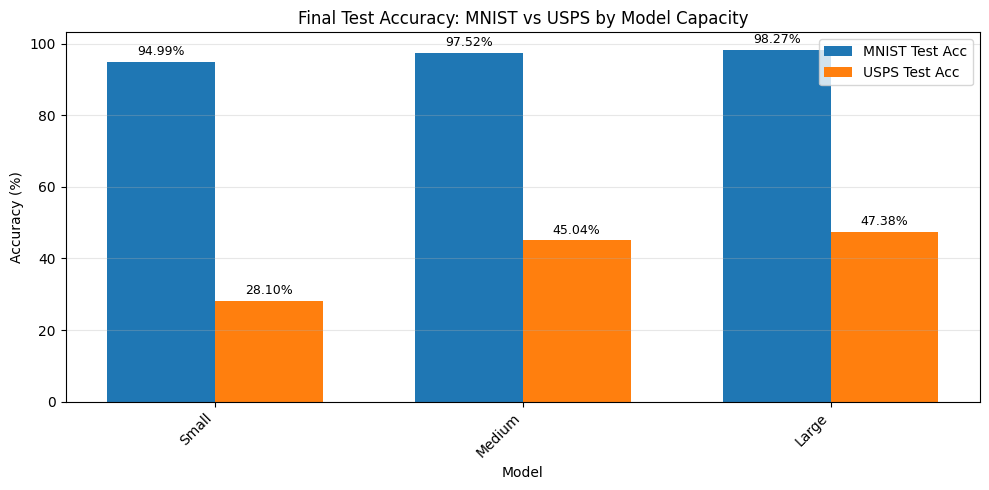

Overfitting Analysis (MNIST vs USPS):
Model			MNIST Test Acc	Train-Test Gap	USPS Acc	MNIST-USPS Gap	Overfitting?
---------------------------------------------------------------------------------------------------------
Small               	94.99%		0.42%		28.10%		66.89%		Yes
Medium              	97.52%		2.07%		45.04%		52.48%		Yes
Large               	98.27%		1.40%		47.38%		50.89%		Yes


In [15]:
# Plot model capacity comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(17, 10))

# Test accuracy
for name in capacity_histories.keys():
    ax1.plot(capacity_histories[name]['test_acc'], label=name, marker='o', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Capacity Impact - MNIST Test Accuracy')
ax1.legend()
ax1.grid(True)

# Train vs Test accuracy for overfitting detection
for name in capacity_histories.keys():
    gap = np.array(capacity_histories[name]['train_acc']) - np.array(capacity_histories[name]['test_acc'])
    ax2.plot(gap, label=name, marker='o', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Train - Test Accuracy Gap (%)')
ax2.set_title('Overfitting Detection (Train-Test Gap) on MNIST')
ax2.legend()
ax2.grid(True)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Train accuracy
for name in capacity_histories.keys():
    ax3.plot(capacity_histories[name]['train_acc'], label=name, marker='o', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Model Capacity Impact - Training Accuracy on MNIST')
ax3.legend()
ax3.grid(True)

# Loss curves - use consistent colors per model
num_models = len(capacity_histories)
colors = plt.cm.tab10(np.linspace(0, 1, max(10, num_models)))  # tab10 provides distinct colors

for idx, name in enumerate(capacity_histories.keys()):
    c = colors[idx % len(colors)]
    ax4.plot(capacity_histories[name]['train_loss'], '--', alpha=0.8, color=c, label=f'{name} (train)', linewidth=2)
    ax4.plot(capacity_histories[name]['test_loss'], '-', alpha=1.0, color=c, label=f'{name} (test)', linewidth=2)

ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.set_title('Train vs Test Loss on MNIST')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True)

plt.tight_layout()
plt.show()

# Compare final test accuracies on MNIST vs USPS for each model
model_names = list(capacity_histories.keys())
mnist_final = [capacity_histories[name]['test_acc'][-1] for name in model_names]
usps_final = [capacity_histories[name]['usps_acc'][-1] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mnist_final, width, label='MNIST Test Acc', color='C0')
bars2 = ax.bar(x + width/2, usps_final, width, label='USPS Test Acc', color='C1')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Final Test Accuracy: MNIST vs USPS by Model Capacity')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate bars with values
ymax = max(max(mnist_final), max(usps_final))
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + ymax*0.01, f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Summary of overfitting including USPS performance
print("Overfitting Analysis (MNIST vs USPS):")
print("Model			MNIST Test Acc	Train-Test Gap	USPS Acc	MNIST-USPS Gap	Overfitting?")
print("-" * 105)
for name in capacity_histories.keys():
    final_test = capacity_histories[name]['test_acc'][-1]
    final_train = capacity_histories[name]['train_acc'][-1]
    final_usps = capacity_histories[name]['usps_acc'][-1]
    gap_mnist = final_train - final_test
    gap_domain = final_test - final_usps
    overfitting = "Yes" if (gap_mnist > 5 or gap_domain > 5) else "No"
    print(f"{name:<20}	{final_test:.2f}%		{gap_mnist:.2f}%		{final_usps:.2f}%		{gap_domain:.2f}%		{overfitting}")


## Part 7 II: USPS Generalization Challenge

Your next task is to tune an MLP that 
- Converges within 20 epochs and
- Reaches **at least 58% accuracy on the USPS test set** while still being trained on the MNIST training data.

Please explore different hidden layer configurations, optimizers, and learning rates. Keep notes on how you iterate so you can explain the path you took to the best result. When you finish, record:
- The optimizer you used
- The learning rate
- The hidden layer sizes
- The number of epochs
- The resulting MNIST and USPS accuracies

Use the sandbox cell below to run your experiments and capture the best-performing configuration.


In [49]:
num_epochs = 20

################################################################################
# TODO: Set up optimizer and model architecture for final experiment
# HINT: Choose a hidden layer configuration and activation function type.
#       Define 'learning_rates' and 'momentum' if using SGD with momentum.
#       Define `learning_rates` and `optimizer_fn` for Adam optimizer.
#       Define 'learning_rates' and 'weight_decay' if using AdamW.
#       Set `hidden_sizes` and `activation_type` for the MLP.
################################################################################
# *****START OF SOLUTION*****

# Optimizer setup
learning_rate =  0.001 # Set an appropriate learning rate
momentum =  0.9 # Set momentum if using SGD
weight_decay =  1e-4 # Set weight decay if using AdamW
optimizer_fn = lambda params: optim.AdamW(
    params,
    lr=learning_rate,
    weight_decay=weight_decay,
) # Define optimizer function here

# Model setup
hidden_sizes =  [128, 64] # Define hidden layer sizes
activation_type =  "relu" # Define activation function type here

# *****END OF SOLUTION*****
################################################################################


# Create MLP with specified hidden_sizes and activation
model = MLP(hidden_sizes=hidden_sizes, activation=activation_type)
model.apply(random_init)  # Re-initialize weights for fair comparison
model = model.to(device)     

# Use the optimizer_fn to create the optimizer

optimizer = optimizer_fn(model.parameters())

# Train model and evaluate on both MNIST and USPS
history = train_model(model, train_loader, test_loader, optimizer, criterion, 
                         num_epochs=num_epochs, device=device, extra_test_loaders={'usps': usps_test_loader})
    # Store results in optimizer_histories dictionary


# Print best USPS accuracy and corresponding epoch
usps_acc_series = history['usps_acc']  # list of per-epoch USPS accuracies
best_val = max(usps_acc_series)
best_epoch = usps_acc_series.index(best_val) + 1  # 1-based epoch

# If accuracy is in [0,1], convert to percent
test_acc = best_val
best_test_acc = best_val * 100.0 if best_val <= 1.0 else best_val

print("=" * 60)
print("BEST USPS TEST ACCURACY")
print("=" * 60)
print(f"Best USPS Test Accuracy: {best_test_acc:.2f}% at epoch {best_epoch}")


Epoch [1/20] - Train Loss: 0.3326, Train Acc: 90.53% - Test Loss: 0.1504, Test Acc: 95.45% - Usps Loss: 2.1123, Usps Acc: 43.10%
Epoch [2/20] - Train Loss: 0.1269, Train Acc: 96.25% - Test Loss: 0.1069, Test Acc: 96.68% - Usps Loss: 1.9092, Usps Acc: 51.67%
Epoch [3/20] - Train Loss: 0.0884, Train Acc: 97.31% - Test Loss: 0.0850, Test Acc: 97.26% - Usps Loss: 2.1756, Usps Acc: 50.07%
Epoch [4/20] - Train Loss: 0.0659, Train Acc: 97.94% - Test Loss: 0.0894, Test Acc: 97.21% - Usps Loss: 2.1538, Usps Acc: 48.03%
Epoch [5/20] - Train Loss: 0.0521, Train Acc: 98.37% - Test Loss: 0.0831, Test Acc: 97.32% - Usps Loss: 2.3573, Usps Acc: 51.07%
Epoch [6/20] - Train Loss: 0.0442, Train Acc: 98.53% - Test Loss: 0.0740, Test Acc: 97.70% - Usps Loss: 2.1408, Usps Acc: 57.80%
Epoch [7/20] - Train Loss: 0.0351, Train Acc: 98.88% - Test Loss: 0.0789, Test Acc: 97.62% - Usps Loss: 2.6238, Usps Acc: 54.66%
Epoch [8/20] - Train Loss: 0.0287, Train Acc: 99.08% - Test Loss: 0.0698, Test Acc: 97.98% - Usps

## Inline Questions

### Question 1
**Activation Functions**: Based on your experiments in Part 4, explain 1) why activation functions are crucial for neural networks. What happens to a multi-layer network without activation functions, and 2) why does this occur mathematically? 3) What is the activation function that you will choose for image classification, and briefly explain the reason.

$\color{blue}{\textit{Your Answer:}}$

1. Activation functions introduce non linearity. Without the activation function, an ML netword would act like a single layer linear model.
2. The activation functions introduce (as explained above) non linearity. This makes learning function input output relationships more accurate and "real".
3. I choose ReLU since it handles vanishing gradients better than Sig and Tanh. This brings about faster convergence.

### Question 2
**Learning Rate Impact**: From your experiments in Part 5, 1) describe what happens when the learning rate is too high versus too low. 2) How can you identify these problems from the training curves? 3) What learning rate would you recommend for each optimizer tested?

$\color{blue}{\textit{Your Answer:}}$

1. Too high: the loss diverges and oscillates too much, mitigating the likelihood of finding the minimum (especially if the function slope is steep). Too low: the loss updates the weights in such small increments that the training can get caught in poor local minima or saddles.
2. High: very jagged loss curves. Low: flat loss curve that has a very slow convergence.
3. If you are using *SGD*, then usually higher rates (e.g. 0.1 and 0.01). *Adam/W* require smaller rates in the $10^{-3} \text{ to } 10^{-4}$ range.

### Question 3
**Optimizer Comparison**: Compare the performance and stability of SGD, Adam, and AdamW from your experiments in Part 6. Why might Adam and AdamW be more robust across different learning rates? In what scenarios might you still prefer SGD?

$\color{blue}{\textit{Your Answer:}}$

*Adam/W* generally converge faster and are more stable due to the use of lower learning rates with their weight decay rather than using momentum. I would prefer *SGD* for generalizations on the test set since it finds "flat" minima better.

### Question 4
**Overfitting Analysis**: In Part 7, examine how model capacity influences overfitting. Explain how to detect overfitting from training curves, and indicate whether a domain gap exists between MNIST and USPS; if so, briefly describe likely causes.

$\color{blue}{\textit{Your Answer:}}$

The wider the model capacity (ie more layers), the more likely the model will begin to memorize even the noise within the training data, which ends up causing poor generalization in the model. The overfitting is found when the training loss continues to fall but the test loss starts rising. Since the model is being trained on the MNIST data, it will begin to specify on the specific characteristics of that dataset and thus generalize poorly to datasets with varying characteristics.

### Question 5
**Hyper-parameters Tuning**: From Part 7 II, what is the best combination of hidden layer configurations, optimizers, and learning rates, that will reach test_acc above 58% on UPSP test set? Birefly explain how you get the current combination.

$\color{blue}{\textit{Your Answer:}}$

I found the best combo to be:
- hidden layer: wide and large [128, 64]
- optimizer: AdamW
- learning rate: 0.001
- weight decay: 1e-4

I got this by using the data from the other experiments, and then applying them to this one. It just makes sense to use the AdamW due to it's ability to converge well with a more stable learning rate.
